# 03_satellite_imagery_processing

Analysis and processing of Planet SuperDove 8-band satellite composites.

**Input:**
- `data/Satellite/*.composite.tif` — 8-band SuperDove composites (3 m/px, EPSG:32630)
- `geospatial/ctd_points.geojson` — 13 CTD sampling locations
- `data/processed/raw_features.parquet` — precomputed band stats (from `02_data_preprocessing`)

**Output:**
- `data/processed/patches/patches_{N}px.npz` — circular image patch datasets (5 crop sizes)
- `images/*.png` — documentation figures

**Planet SuperDove band order:**

| Index (0-based) | Band       | Wavelength |
|-----------------|------------|------------|
| 0               | Coastal    | 443 nm     |
| 1               | Blue       | 490 nm     |
| 2               | Green I    | 531 nm     |
| 3               | Green      | 565 nm     |
| 4               | Yellow     | 610 nm     |
| 5               | Red        | 665 nm     |
| 6               | Red Edge   | 705 nm     |
| 7               | NIR        | 865 nm     |

**Circular patches:**  
Each crop is a circle inscribed in the bounding square. Pixels outside the circle
are set to NaN so that statistics and DL models only process the sampling area.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

matplotlib.rcParams["figure.dpi"] = 100
matplotlib.rcParams["font.size"] = 9

## Configuration

In [2]:
CTD_GEOJSON   = Path("../geospatial/ctd_points.geojson")
SATELLITE_DIR = Path("../data/Satellite")
PROCESSED_DIR = Path("../data/processed")
PATCHES_DIR   = PROCESSED_DIR / "patches"
IMAGES_DIR    = Path("../images")

for d in [PATCHES_DIR, IMAGES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BAND_NAMES  = ["coastal", "blue", "green_i", "green", "yellow", "red", "red_edge", "nir"]
BAND_COLORS = ["#5566aa", "#4477cc", "#44aa66", "#22cc44",
               "#ddcc22", "#cc4422", "#aa2244", "#660022"]

RGB_BANDS = (5, 3, 1)   # Red, Green, Blue  → natural colour
CIR_BANDS = (7, 5, 3)   # NIR, Red, Green   → colour-infrared

PIXEL_SIZE_M = 3.0

# Five patch sizes: pixels × pixels  (ground footprint = px × 3 m)
PATCH_CONFIGS = [
    {"px": 16,  "metres": 48,  "label": "16 px / 48 m"},
    {"px": 32,  "metres": 96,  "label": "32 px / 96 m"},
    {"px": 64,  "metres": 192, "label": "64 px / 192 m"},
    {"px": 128, "metres": 384, "label": "128 px / 384 m"},
    {"px": 256, "metres": 768, "label": "256 px / 768 m"},
]

# Minimum fraction of circle pixels that must be non-nodata
MIN_VALID_FRACTION = 0.80

pd.DataFrame(PATCH_CONFIGS).set_index("px")

,metres,label
px,,
16,48,16 px / 48 m
32,96,32 px / 96 m
64,192,64 px / 192 m
128,384,128 px / 384 m
256,768,256 px / 768 m


## Load data

In [32]:
ctd = gpd.read_file(CTD_GEOJSON).set_crs("EPSG:4326")
print(f"CTD points: {len(ctd)}")

tif_files = sorted(
    f for f in SATELLITE_DIR.glob("*composite.tif")
    if re.search(r"\d{4}-\d{2}-\d{2}", f.name)
)

valid_tifs = []
for f in tif_files:
    try:
        with rasterio.open(f) as src:
            if src.count == 8:
                valid_tifs.append(f)
    except Exception:
        pass

print(f"Valid 8-band images: {len(valid_tifs)}")

import random
SAMPLE_TIF  = random.choice(valid_tifs)
SAMPLE_DATE = re.search(r"(\d{4}-\d{2}-\d{2})", SAMPLE_TIF.name).group(1)
print(f"Sample image: {SAMPLE_TIF.name}")

CTD points: 12
Valid 8-band images: 56
Sample image: 2023-02-04_strip_6261761_composite.tif


---
## Image analysis
### Band statistics

In [16]:
with rasterio.open(SAMPLE_TIF) as src:
    nodata = src.nodata
    image  = src.read().astype("float32")

image[image == nodata] = np.nan

rows = []
for i, name in enumerate(BAND_NAMES):
    v = image[i].ravel()
    v = v[~np.isnan(v)]
    rows.append({
        "band":     name,
        "min":      int(v.min()),
        "p2":       int(np.percentile(v, 2)),
        "mean":     int(v.mean()),
        "median":   int(np.median(v)),
        "p98":      int(np.percentile(v, 98)),
        "max":      int(v.max()),
        "std":      int(v.std()),
        "valid_px": len(v),
    })

stats_df = pd.DataFrame(rows).set_index("band")
print(f"Image: {SAMPLE_DATE}  —  {image.shape[1]} x {image.shape[2]} px")
stats_df

Image: 2024-05-22  —  7277 x 4464 px


,min,p2,mean,median,p98,max,std,valid_px
band,,,,,,,,
coastal,1,407,843,635,2904,9895,603,22837729
blue,138,468,933,679,3061,9291,634,22837729
green_i,195,516,1078,807,3271,10453,696,22837729
green,224,532,1216,918,3499,11336,789,22837729
yellow,120,461,1322,825,3925,12514,983,22837729
red,168,461,1335,742,3942,13043,1016,22837729
red_edge,1,383,1448,678,4193,12595,1158,22837729
nir,16,378,1829,648,5038,12399,1551,22837729


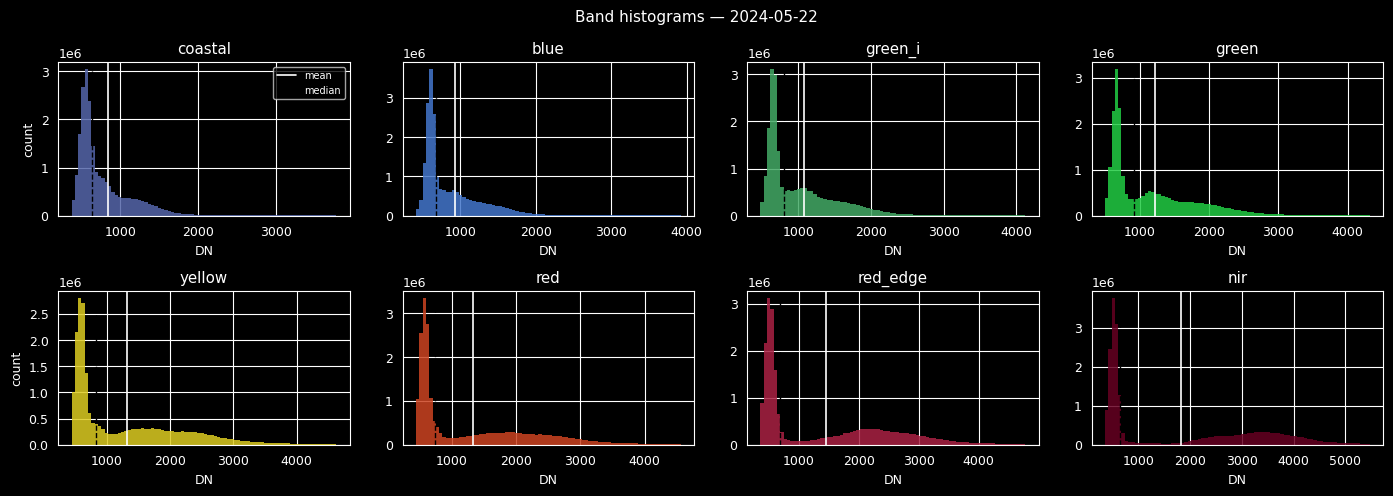

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
fig.suptitle(f"Band histograms — {SAMPLE_DATE}", fontsize=11)

for i, (ax, name, colour) in enumerate(zip(axes.flat, BAND_NAMES, BAND_COLORS)):
    v = image[i].ravel()
    v = v[~np.isnan(v)]
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    ax.hist(v, bins=80, range=(lo, hi), color=colour, alpha=0.85, edgecolor="none")
    ax.axvline(v.mean(),     color="white", lw=1.2, label="mean")
    ax.axvline(np.median(v), color="black", lw=1.0, ls="--", label="median")
    ax.set_title(name)
    ax.set_xlabel("DN")
    ax.set_ylabel("count" if i % 4 == 0 else "")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

axes.flat[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

### Band correlation

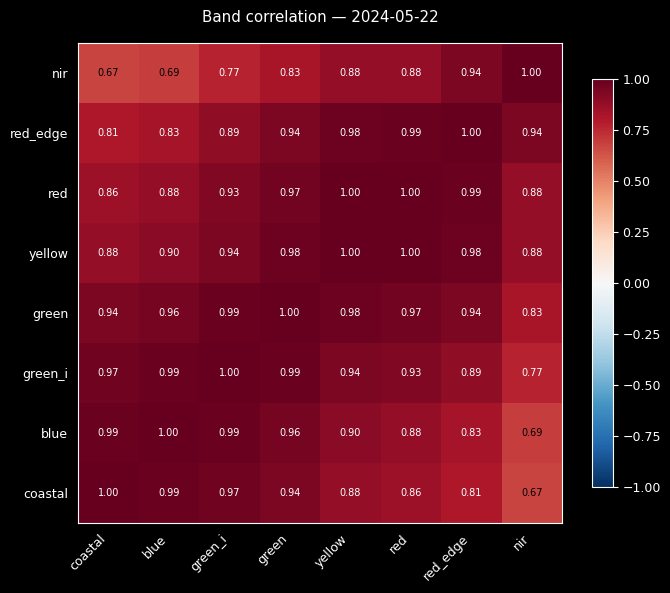

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))

x = np.arange(9)
y = np.arange(9)

im = ax.pcolormesh(
    x, y, corr,
    vmin=-1, vmax=1,
    cmap="RdBu_r",
    shading="auto"
)

plt.colorbar(im, ax=ax, shrink=0.85)

ax.set_xticks(np.arange(8) + 0.5)
ax.set_yticks(np.arange(8) + 0.5)
ax.set_xticklabels(BAND_NAMES, rotation=45, ha="right")
ax.set_yticklabels(BAND_NAMES)

ax.set_title(f"Band correlation — {SAMPLE_DATE}", pad=15)

for r in range(8):
    for c in range(8):
        ax.text(c + 0.5, r + 0.5, f"{corr[r, c]:.2f}",
                ha="center", va="center", fontsize=7,
                color="black" if abs(corr[r, c]) < 0.7 else "white")

plt.tight_layout()
plt.show()

### Temporal evolution of band means

In [25]:
temporal_rows = []

for f in tqdm(valid_tifs, desc="Computing image means"):
    date_str = re.search(r"(\d{4}-\d{2}-\d{2})", f.name).group(1)
    with rasterio.open(f) as src:
        nd  = src.nodata
        img = src.read().astype("float32")
    img[img == nd] = np.nan
    row = {"date": pd.to_datetime(date_str)}
    for i, name in enumerate(BAND_NAMES):
        row[name] = float(np.nanmean(img[i]))
    temporal_rows.append(row)

temporal_df = pd.DataFrame(temporal_rows).set_index("date").sort_index()
temporal_df.head()

Computing image means: 100%|██████████| 56/56 [01:55<00:00,  2.07s/it]


,coastal,blue,green_i,green,yellow,red,red_edge,nir
date,,,,,,,,
2021-08-24,9024.110352,8442.150391,7555.244141,7222.778809,6687.225586,5867.792969,5401.134766,4226.078613
2021-08-24,8391.690430,7823.672852,6986.754883,6619.803223,6041.354980,5420.188477,4862.722656,3864.506348
2021-08-26,6167.805176,5248.351074,4348.356934,3967.296387,3398.472656,2994.235352,2690.420654,2020.499390
2021-09-12,6157.218262,5176.781250,4386.121094,4132.397461,3747.450928,3347.190430,3146.808594,2685.192871
2021-09-30,6888.811035,5880.884766,4944.274414,4527.929199,3993.200195,3460.544922,3181.003662,2589.159668


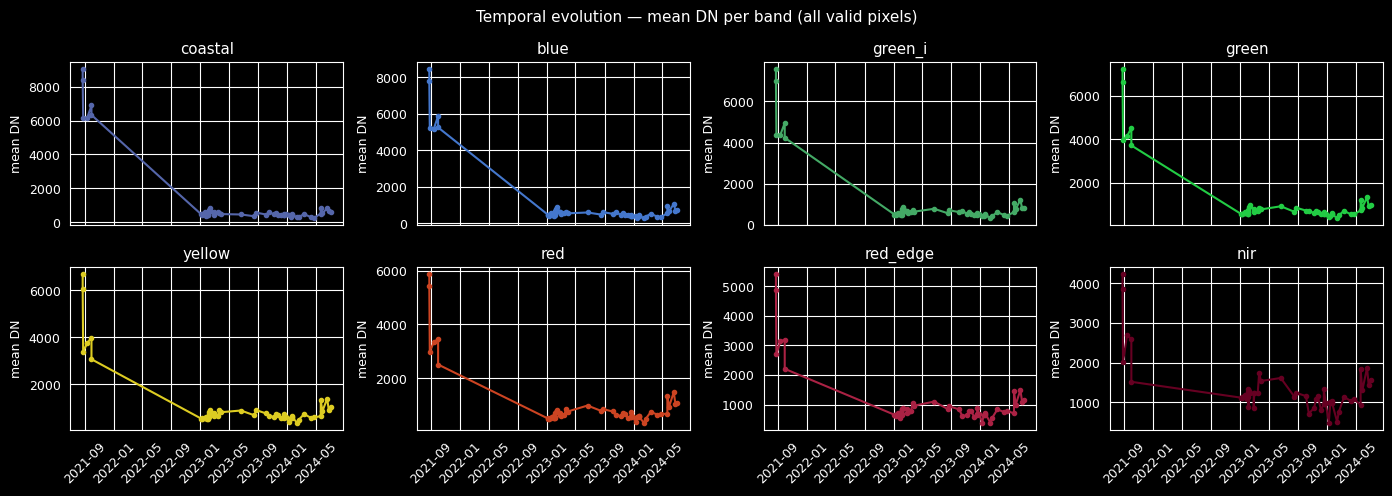

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5), sharex=True)
fig.suptitle("Temporal evolution — mean DN per band (all valid pixels)", fontsize=11)

for ax, name, colour in zip(axes.flat, BAND_NAMES, BAND_COLORS):
    ax.plot(temporal_df.index, temporal_df[name], color=colour, lw=1.5, marker="o", ms=3)
    ax.set_title(name)
    ax.set_ylabel("mean DN")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Per-CTD band profiles

Box plots of the green and NIR band means per station across all dates.
Uses `raw_features.parquet` from `02_data_preprocessing`.

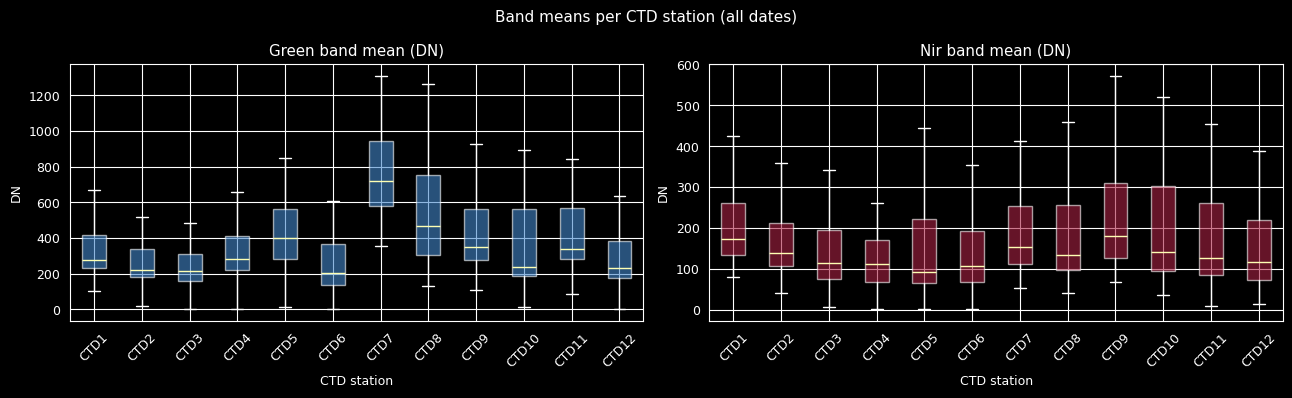

In [27]:
raw_path = PROCESSED_DIR / "raw_features.parquet"

if raw_path.exists():
    raw = pd.read_parquet(raw_path)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("Band means per CTD station (all dates)", fontsize=11)

    for ax, band in zip(axes, ["green_mean", "nir_mean"]):
        order = sorted(raw["ctd"].unique(), key=lambda x: int(x.replace("CTD", "")))
        groups = [raw.loc[raw["ctd"] == s, band].values for s in order]
        bp = ax.boxplot(groups, patch_artist=True, showfliers=False)
        colour = "#4488cc" if "green" in band else "#aa2244"
        for patch in bp["boxes"]:
            patch.set_facecolor(colour); patch.set_alpha(0.6)
        ax.set_xticklabels(order, rotation=45)
        ax.set_title(band.replace("_mean", "").capitalize() + " band mean (DN)")
        ax.set_ylabel("DN"); ax.set_xlabel("CTD station")

    plt.tight_layout()
    plt.show()
else:
    print("raw_features.parquet not found — run 02_data_preprocessing first.")

---
## Visualisation helpers

In [28]:
def get_circle_mask(patch_px: int) -> np.ndarray:
    """Boolean (patch_px, patch_px) mask: True inside the inscribed circle."""
    half_px = patch_px / 2.0
    yy, xx  = np.ogrid[:patch_px, :patch_px]
    return (xx - half_px + 0.5) ** 2 + (yy - half_px + 0.5) ** 2 <= half_px ** 2


def percentile_stretch(image: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    """Clip each band to [p_low, p_high] percentile and rescale to [0, 1]."""
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        lo  = np.nanpercentile(image[i], p_low)
        hi  = np.nanpercentile(image[i], p_high)
        out[i] = np.clip((image[i] - lo) / (hi - lo + 1e-6), 0, 1)
    return out


def make_composite(image: np.ndarray, band_indices: tuple) -> np.ndarray:
    """Return (H, W, 3) uint8 display array from selected bands (NaN → black)."""
    stretched = percentile_stretch(image)
    rgb = np.stack([stretched[b] for b in band_indices], axis=-1)
    return (np.nan_to_num(rgb, nan=0.0) * 255).astype(np.uint8)


def add_circle_overlay(ax, patch_px: int, **kwargs):
    """Draw the inscribed circle boundary on a patch axes."""
    defaults = dict(fill=False, edgecolor="white", lw=0.9, ls="--", zorder=8)
    defaults.update(kwargs)
    cx = cy = (patch_px - 1) / 2.0
    r  = patch_px / 2.0
    ax.add_patch(mpatches.Circle((cx, cy), r, **defaults))


def ctd_pixel_coords(ctd_gdf, src):
    """Return list of (name, col, row) pixel coords for each CTD in the raster CRS."""
    proj = ctd_gdf.to_crs(src.crs)
    return [(row["ControlPointCode"], *src.index(row.geometry.x, row.geometry.y)[::-1])
            for _, row in proj.iterrows()]

## Full-image RGB & CIR composites with CTD overlay

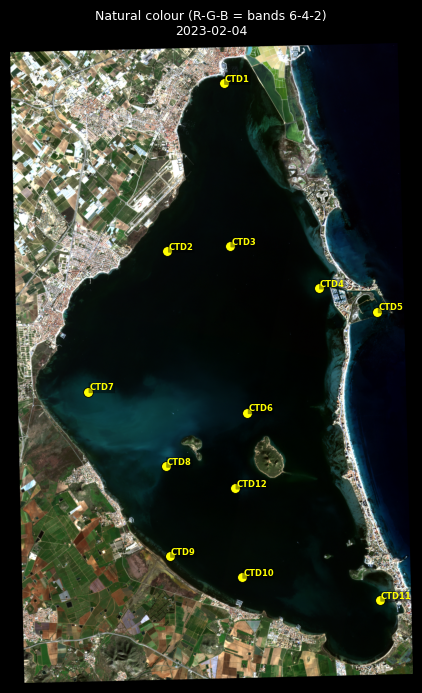

In [34]:
with rasterio.open(SAMPLE_TIF) as src:
    nd = src.nodata
    image = src.read().astype("float32")
    image[image == nd] = np.nan
    coords = ctd_pixel_coords(ctd, src)

rgb_img = make_composite(image, RGB_BANDS)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

ax.imshow(rgb_img)
for name, cx_, ry_ in coords:
    ax.scatter(cx_, ry_, s=50, c="yellow", edgecolors="black", lw=0.6, zorder=5)
    ax.text(cx_ + 15, ry_ - 15, name, color="yellow", fontsize=6, fontweight="bold",
            zorder=6, bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.4, lw=0))

ax.set_title(f"Natural colour (R-G-B = bands 6-4-2)\n{SAMPLE_DATE}", fontsize=9)
ax.axis("off")

plt.tight_layout()
plt.show()

---
## Circular crop visualisation

### Extract patch function

Each patch is a circle inscribed in the bounding square.
Corners (outside the circle) are set to NaN.
A patch is rejected if fewer than `MIN_VALID_FRACTION` of its circle pixels are valid.

In [35]:
def extract_patch_array(
    src: rasterio.DatasetReader,
    cx: float,
    cy: float,
    patch_px: int,
    nodata=None,
    min_valid: float = 0.80,
) -> np.ndarray | None:
    """
    Extract a circular patch of shape (nbands, patch_px, patch_px) centred at (cx, cy).

    Steps:
    1. Build the bounding square window in raster coordinates.
    2. Reject if the window extends outside the image.
    3. Read and resample to (nbands, patch_px, patch_px).
    4. Replace raster nodata with NaN.
    5. Apply inscribed circle mask (corners → NaN).
    6. Reject if fewer than `min_valid` fraction of circle pixels are non-NaN.

    Returns the float32 patch array or None.
    """
    half = (patch_px / 2) * src.res[0]
    win  = from_bounds(cx - half, cy - half, cx + half, cy + half, src.transform)

    if (win.col_off < 0 or win.row_off < 0
            or win.col_off + win.width  > src.width
            or win.row_off + win.height > src.height):
        return None

    patch = src.read(
        window=win,
        out_shape=(src.count, patch_px, patch_px),
        resampling=rasterio.enums.Resampling.bilinear,
    ).astype(np.float32)

    if nodata is not None:
        patch[patch == nodata] = np.nan

    # Build inscribed circle mask
    circle = get_circle_mask(patch_px)

    # Validate: enough non-nodata pixels inside circle
    nan_in_circle  = np.any(np.isnan(patch), axis=0) & circle
    valid_fraction = 1.0 - nan_in_circle.sum() / circle.sum()
    if valid_fraction < min_valid:
        return None

    # Set corners (outside circle) to NaN
    patch[:, ~circle] = np.nan
    return patch

### Multi-size crop comparison

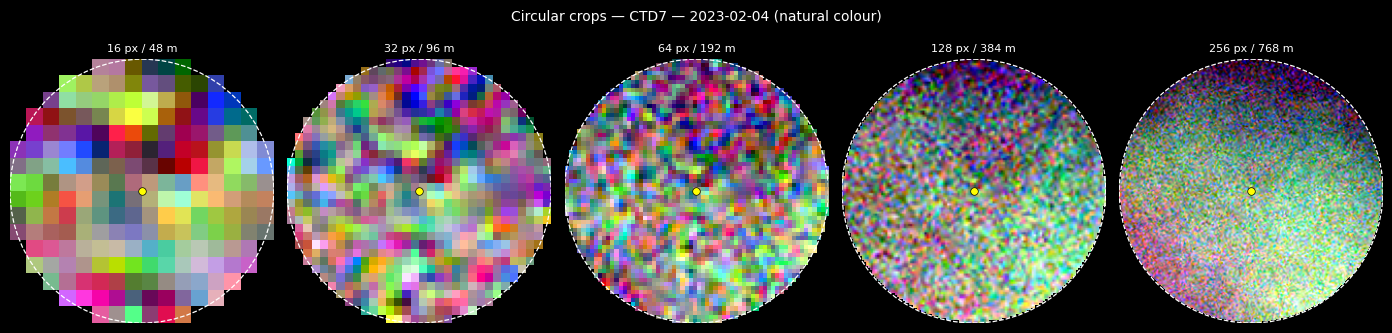

In [46]:
DEMO_CTD = "CTD7"

with rasterio.open(SAMPLE_TIF) as src:
    nd = src.nodata
    ctd_proj = ctd.to_crs(src.crs)
    point = ctd_proj.loc[ctd_proj["ControlPointCode"] == DEMO_CTD, "geometry"].iloc[0]
    cx, cy = point.x, point.y

    patches = [
        extract_patch_array(
            src, cx, cy, cfg["px"],
            nodata=nd,
            min_valid=MIN_VALID_FRACTION
        )
        for cfg in PATCH_CONFIGS
    ]

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
fig.suptitle(f"Circular crops — {DEMO_CTD} — {SAMPLE_DATE} (natural colour)", fontsize=10)

for ax, cfg, patch in zip(axes, PATCH_CONFIGS, patches):
    if patch is None:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue

    rgb = patch[np.array(RGB_BANDS) - 1].astype("float32")

    for i in range(3):
        p2, p98 = np.nanpercentile(rgb[i], (2, 98))
        rgb[i] = np.clip((rgb[i] - p2) / (p98 - p2 + 1e-6), 0, 1)

    rgb = np.transpose(rgb, (1, 2, 0))

    ax.imshow(rgb)

    mid = (cfg["px"] - 1) / 2
    ax.scatter(mid, mid, s=30, c="yellow", edgecolors="black", lw=0.5, zorder=9)
    add_circle_overlay(ax, cfg["px"])

    ax.set_title(cfg["label"], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### All CTD stations — 64 px crop

Quality-check grid: each cell shows the 64 px circular crop around one CTD station.
Useful for detecting cloud cover, land contamination or sensor artefacts.

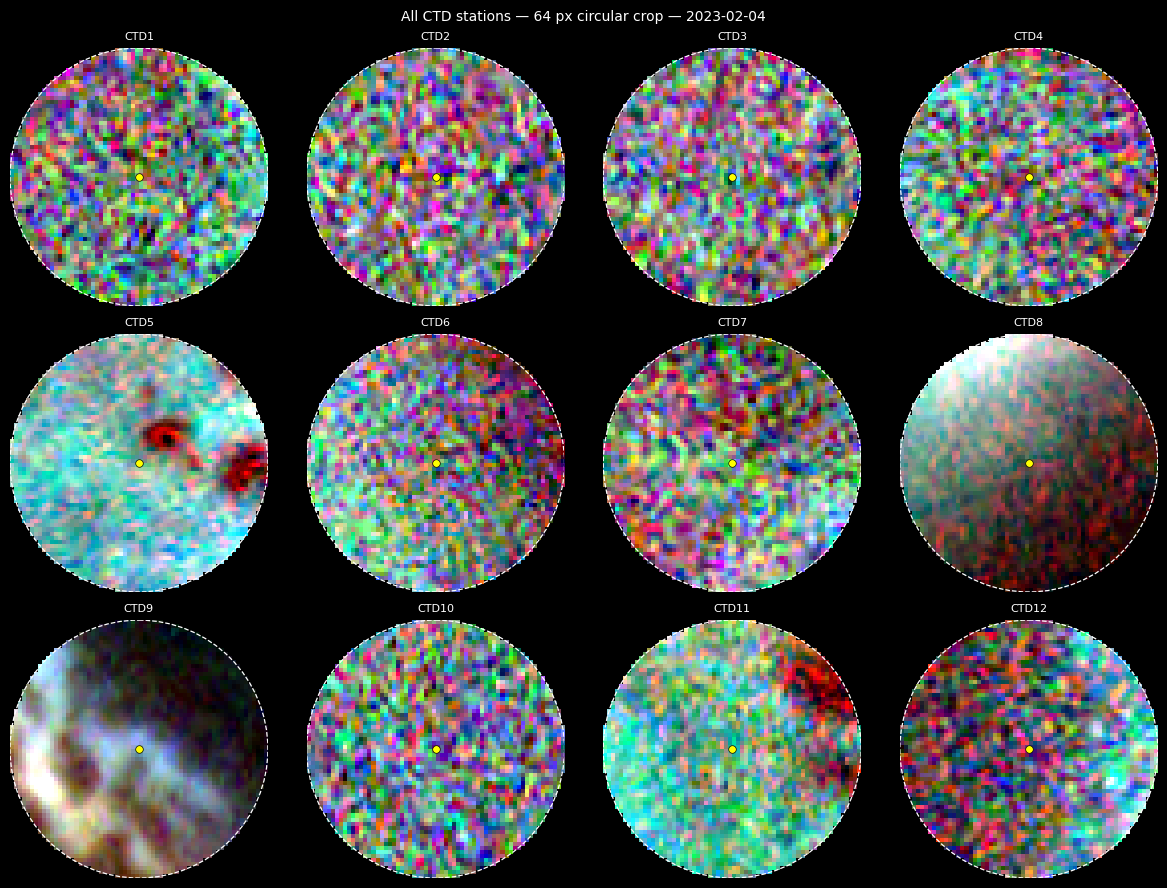

In [47]:
GRID_PATCH_PX = 64

with rasterio.open(SAMPLE_TIF) as src:
    nd       = src.nodata
    ctd_proj = ctd.to_crs(src.crs)
    stations = sorted(ctd_proj["ControlPointCode"].tolist(),
                      key=lambda x: int(x.replace("CTD", "")))
    grid_data = {
        row["ControlPointCode"]: extract_patch_array(
            src, row.geometry.x, row.geometry.y,
            GRID_PATCH_PX, nodata=nd, min_valid=MIN_VALID_FRACTION)
        for _, row in ctd_proj.iterrows()
    }

n_cols = 4
n_rows = -(-len(stations) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
fig.suptitle(f"All CTD stations — {GRID_PATCH_PX} px circular crop — {SAMPLE_DATE}",
             fontsize=10)

for ax, station in zip(axes.flat, stations):
    patch = grid_data.get(station)
    if patch is None:
        ax.text(0.5, 0.5, f"{station}\nN/A", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="grey")
    else:
        ax.imshow(make_composite(patch, RGB_BANDS))
        mid = (GRID_PATCH_PX - 1) / 2
        ax.scatter(mid, mid, s=30, c="yellow", edgecolors="black", lw=0.5, zorder=9)
        add_circle_overlay(ax, GRID_PATCH_PX)
    ax.set_title(station, fontsize=8)
    ax.axis("off")

for ax in axes.flat[len(stations):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Context view — crop location on full scene

Shows the position of one circular crop within the full satellite image.

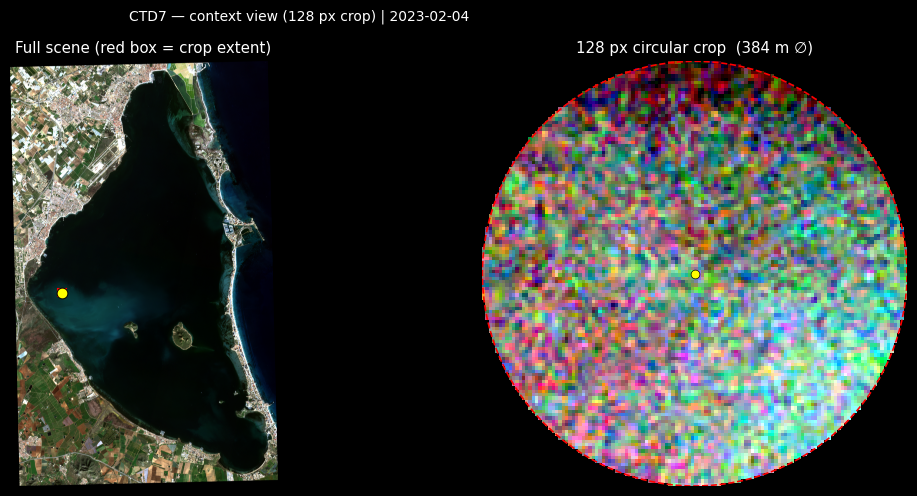

In [51]:
CONTEXT_CTD = "CTD7"
CONTEXT_PX  = 128

with rasterio.open(SAMPLE_TIF) as src:
    nd       = src.nodata
    img_full = src.read().astype("float32")
    img_full[img_full == nd] = np.nan
    ctd_proj = ctd.to_crs(src.crs)
    pt       = ctd_proj.loc[ctd_proj["ControlPointCode"] == CONTEXT_CTD, "geometry"].iloc[0]
    cx, cy   = pt.x, pt.y
    row_c, col_c = src.index(cx, cy)  # (col, row) for matplotlib
    patch_ctx    = extract_patch_array(src, cx, cy, CONTEXT_PX, nodata=nd)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})
fig.suptitle(f"{CONTEXT_CTD} — context view ({CONTEXT_PX} px crop) | {SAMPLE_DATE}",
             fontsize=10)

axes[0].imshow(make_composite(img_full, RGB_BANDS))
half_px = CONTEXT_PX / 2
rect = mpatches.Rectangle((col_c - half_px, row_c - half_px), CONTEXT_PX, CONTEXT_PX,
                            lw=1.5, edgecolor="red", facecolor="none", zorder=5)
axes[0].add_patch(rect)
axes[0].scatter(col_c, row_c, s=60, c="yellow", edgecolors="black", lw=0.7, zorder=6)
axes[0].set_title("Full scene (red box = crop extent)"); axes[0].axis("off")

if patch_ctx is not None:
    axes[1].imshow(make_composite(patch_ctx, RGB_BANDS))
    mid = (CONTEXT_PX - 1) / 2
    axes[1].scatter(mid, mid, s=40, c="yellow", edgecolors="black", lw=0.5, zorder=9)
    add_circle_overlay(axes[1], CONTEXT_PX, edgecolor="red", lw=1.2)
axes[1].set_title(f"{CONTEXT_PX} px circular crop  ({CONTEXT_PX * 3} m ∅)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

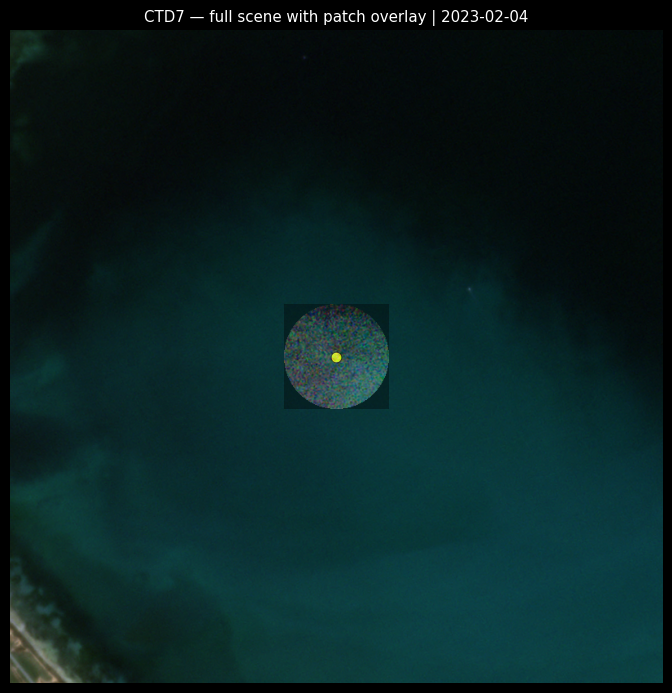

In [56]:
CONTEXT_CTD = "CTD7"
CONTEXT_PX  = 128

with rasterio.open(SAMPLE_TIF) as src:
    nd       = src.nodata
    img_full = src.read().astype("float32")
    img_full[img_full == nd] = np.nan

    ctd_proj = ctd.to_crs(src.crs)
    pt = ctd_proj.loc[
        ctd_proj["ControlPointCode"] == CONTEXT_CTD,
        "geometry"
    ].iloc[0]

    cx, cy = pt.x, pt.y
    row_c, col_c = src.index(cx, cy)

    patch_ctx = extract_patch_array(src, cx, cy, CONTEXT_PX, nodata=nd)


fig, ax = plt.subplots(1, 1, figsize=(7, 7))

ax.imshow(make_composite(img_full, RGB_BANDS))

half_px = CONTEXT_PX / 2

ax.scatter(col_c, row_c, s=60, c="yellow", edgecolors="black", lw=0.7, zorder=6)

if patch_ctx is not None:
    ax.imshow(
        make_composite(patch_ctx, RGB_BANDS),
        extent=[
            col_c - half_px, col_c + half_px,
            row_c + half_px, row_c - half_px
        ],
        alpha=0.35,
        zorder=7
    )

ax.set_title(f"{CONTEXT_CTD} — full scene with patch overlay | {SAMPLE_DATE}")
ax.axis("off")

zoom = 400
ax.set_xlim(col_c - zoom, col_c + zoom)
ax.set_ylim(row_c + zoom, row_c - zoom)

plt.tight_layout()
plt.show()

---
## Multi-scale circular patch dataset extraction

For each of the five crop sizes, all valid images × all CTD stations are processed.
Rejected patches (outside image bounds or > 20 % nodata in circle) are discarded
and logged so downstream notebooks know the actual coverage.

**Output files** in `data/processed/patches/`:

| File              | Array `X` shape      | Circle ∅  |
|-------------------|----------------------|-----------|
| patches_16px.npz  | (N, 8,  16,  16)     | 48 m      |
| patches_32px.npz  | (N, 8,  32,  32)     | 96 m      |
| patches_64px.npz  | (N, 8,  64,  64)     | 192 m     |
| patches_128px.npz | (N, 8, 128, 128)     | 384 m     |
| patches_256px.npz | (N, 8, 256, 256)     | 768 m     |

Each file contains arrays `X` (float32, NaN at corners), `ctd` (str), `date` (str).

In [72]:
size_buffers = {cfg["px"]: {"X": [], "ctd": [], "date": []}
                for cfg in PATCH_CONFIGS}
rejected     = {cfg["px"]: 0 for cfg in PATCH_CONFIGS}

for tif_path in tqdm(valid_tifs, desc="Extracting patches"):
    date_str = re.search(r"(\d{4}-\d{2}-\d{2})", tif_path.name).group(1)

    with rasterio.open(tif_path) as src:
        nd       = src.nodata
        ctd_proj = ctd.to_crs(src.crs)

        for _, row in ctd_proj.iterrows():
            cx, cy = row.geometry.x, row.geometry.y

            for cfg in PATCH_CONFIGS:
                patch = extract_patch_array(
                    src, cx, cy, cfg["px"],
                    nodata=nd, min_valid=MIN_VALID_FRACTION,
                )
                buf = size_buffers[cfg["px"]]
                if patch is not None:
                    buf["X"].append(patch)
                    buf["ctd"].append(row["ControlPointCode"])
                    buf["date"].append(date_str)
                else:
                    rejected[cfg["px"]] += 1

print("\nExtraction summary:")
print(f"{'Size':>8}  {'Accepted':>9}  {'Rejected':>9}  {'Accept %':>9}")
for cfg in PATCH_CONFIGS:
    n_ok  = len(size_buffers[cfg["px"]]["X"])
    n_rej = rejected[cfg["px"]]
    total = n_ok + n_rej
    pct   = 100 * n_ok / total if total else 0
    print(f"{cfg['label']:>20}  {n_ok:>9}  {n_rej:>9}  {pct:>8.1f}%")

Extracting patches: 100%|██████████| 56/56 [00:13<00:00,  4.17it/s]


Extraction summary:
    Size   Accepted   Rejected   Accept %
        16 px / 48 m        593         79      88.2%
        32 px / 96 m        593         79      88.2%
       64 px / 192 m        593         79      88.2%
      128 px / 384 m        593         79      88.2%
      256 px / 768 m        593         79      88.2%


In [73]:
for cfg in PATCH_CONFIGS:
    px  = cfg["px"]
    buf = size_buffers[px]

    if not buf["X"]:
        print(f"  {px}px — no valid samples, skipping")
        continue

    out_path = PATCHES_DIR / f"patches_{px}px.npz"
    np.savez(
        out_path,
        X    = np.stack(buf["X"]),       # (N, 8, px, px)  float32
        ctd  = np.array(buf["ctd"]),
        date = np.array(buf["date"]),
    )
    size_mb = out_path.stat().st_size / 1e6
    print(f"  Saved {out_path.name:30s}  {len(buf['X']):4d} samples  {size_mb:.1f} MB")

  Saved patches_16px.npz                 593 samples  4.9 MB
  Saved patches_32px.npz                 593 samples  19.5 MB
  Saved patches_64px.npz                 593 samples  77.8 MB
  Saved patches_128px.npz                593 samples  310.9 MB
  Saved patches_256px.npz                593 samples  1243.6 MB


In [74]:
# Coverage table: samples per CTD station × patch size
summary_rows = []
for cfg in PATCH_CONFIGS:
    buf = size_buffers[cfg["px"]]
    if not buf["ctd"]:
        continue
    counts = pd.Series(buf["ctd"]).value_counts().sort_index()
    for station, n in counts.items():
        summary_rows.append({"patch_size": cfg["label"], "ctd": station, "n": n})

if summary_rows:
    summary_df = pd.DataFrame(summary_rows).pivot(index="ctd", columns="patch_size", values="n")
    print("Samples per CTD station and patch size:")
    display(summary_df)

Samples per CTD station and patch size:


patch_size,128 px / 384 m,16 px / 48 m,256 px / 768 m,32 px / 96 m,64 px / 192 m
ctd,,,,,
CTD1,52,52,52,52,52
CTD10,49,49,49,49,49
CTD11,44,44,44,44,44
CTD12,50,50,50,50,50
CTD2,51,51,51,51,51
CTD3,53,53,53,53,53
CTD4,48,48,48,48,48
CTD5,46,46,46,46,46
CTD6,50,50,50,50,50


---
## Save documentation images

High-resolution PNG files saved to `images/` for reports and documentation.

In [75]:
# 1. RGB and CIR overview with CTD overlay
with rasterio.open(SAMPLE_TIF) as src:
    nd     = src.nodata
    img    = src.read().astype("float32"); img[img == nd] = np.nan
    coords = ctd_pixel_coords(ctd, src)

for comp_name, bands in [("rgb", RGB_BANDS), ("cir", CIR_BANDS)]:
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(make_composite(img, bands))
    for name, cx_, ry_ in coords:
        ax.scatter(cx_, ry_, s=60, c="yellow", edgecolors="black", lw=0.7, zorder=5)
        ax.text(cx_ + 15, ry_ - 15, name, color="yellow", fontsize=6, fontweight="bold",
                zorder=6, bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.4, lw=0))
    label = "Natural colour (R-G-B)" if comp_name == "rgb" else "Colour-infrared (NIR-R-G)"
    ax.set_title(f"{label} — {SAMPLE_DATE}", fontsize=10); ax.axis("off")
    out = IMAGES_DIR / f"{comp_name}_overview_{SAMPLE_DATE}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.close()
    print(f"Saved {out}")

Saved ../images/rgb_overview_2024-07-03.png
Saved ../images/cir_overview_2024-07-03.png


In [76]:
# 2. Band histograms
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
fig.suptitle(f"Band histograms — {SAMPLE_DATE}", fontsize=11)

with rasterio.open(SAMPLE_TIF) as src:
    nd  = src.nodata
    img = src.read().astype("float32"); img[img == nd] = np.nan

for i, (ax, name, colour) in enumerate(zip(axes.flat, BAND_NAMES, BAND_COLORS)):
    v = img[i].ravel(); v = v[~np.isnan(v)]
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    ax.hist(v, bins=80, range=(lo, hi), color=colour, alpha=0.85, edgecolor="none")
    ax.axvline(v.mean(), color="white", lw=1.2)
    ax.set_title(name); ax.set_xlabel("DN")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.tight_layout()
out = IMAGES_DIR / "band_histograms.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.close()
print(f"Saved {out}")

Saved ../images/band_histograms.png


In [77]:
# 3. Circular crop size comparison
with rasterio.open(SAMPLE_TIF) as src:
    nd       = src.nodata
    ctd_proj = ctd.to_crs(src.crs)
    pt       = ctd_proj.loc[ctd_proj["ControlPointCode"] == DEMO_CTD, "geometry"].iloc[0]
    patches  = [extract_patch_array(src, pt.x, pt.y, cfg["px"],
                                    nodata=nd, min_valid=MIN_VALID_FRACTION)
                for cfg in PATCH_CONFIGS]

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
fig.suptitle(f"Circular crop sizes — {DEMO_CTD} — {SAMPLE_DATE}", fontsize=10)
for ax, cfg, patch in zip(axes, PATCH_CONFIGS, patches):
    if patch is None:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.imshow(make_composite(patch, RGB_BANDS))
        mid = (cfg["px"] - 1) / 2
        ax.scatter(mid, mid, s=30, c="yellow", edgecolors="black", lw=0.5, zorder=9)
        add_circle_overlay(ax, cfg["px"])
    ax.set_title(cfg["label"], fontsize=8); ax.axis("off")

plt.tight_layout()
out = IMAGES_DIR / "crop_sizes_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.close()
print(f"Saved {out}")

Saved ../images/crop_sizes_comparison.png


In [78]:
# 4. All-CTD crop grid
with rasterio.open(SAMPLE_TIF) as src:
    nd       = src.nodata
    ctd_proj = ctd.to_crs(src.crs)
    stations = sorted(ctd_proj["ControlPointCode"].tolist(),
                      key=lambda x: int(x.replace("CTD", "")))
    grid_patches = {
        row["ControlPointCode"]: extract_patch_array(
            src, row.geometry.x, row.geometry.y,
            GRID_PATCH_PX, nodata=nd, min_valid=MIN_VALID_FRACTION)
        for _, row in ctd_proj.iterrows()
    }

n_cols = 4; n_rows = -(-len(stations) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
fig.suptitle(f"All CTD — {GRID_PATCH_PX} px circular crop — {SAMPLE_DATE}", fontsize=10)

for ax, station in zip(axes.flat, stations):
    patch = grid_patches.get(station)
    if patch is None:
        ax.text(0.5, 0.5, f"{station}\nN/A", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="grey")
    else:
        ax.imshow(make_composite(patch, RGB_BANDS))
        mid = (GRID_PATCH_PX - 1) / 2
        ax.scatter(mid, mid, s=30, c="yellow", edgecolors="black", lw=0.5, zorder=9)
        add_circle_overlay(ax, GRID_PATCH_PX)
    ax.set_title(station, fontsize=8); ax.axis("off")
for ax in axes.flat[len(stations):]:
    ax.set_visible(False)

plt.tight_layout()
out = IMAGES_DIR / f"crops_grid_{SAMPLE_DATE}.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.close()
print(f"Saved {out}")

Saved ../images/crops_grid_2024-07-03.png


In [79]:
# 5. Context view
with rasterio.open(SAMPLE_TIF) as src:
    nd       = src.nodata
    img_full = src.read().astype("float32"); img_full[img_full == nd] = np.nan
    ctd_proj = ctd.to_crs(src.crs)
    pt       = ctd_proj.loc[ctd_proj["ControlPointCode"] == CONTEXT_CTD, "geometry"].iloc[0]
    row_c, col_c = src.index(pt.x, pt.y)[::-1]
    patch_ctx    = extract_patch_array(src, pt.x, pt.y, CONTEXT_PX, nodata=nd)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [2, 1]})
fig.suptitle(f"{CONTEXT_CTD} — context view — {SAMPLE_DATE}", fontsize=10)

axes[0].imshow(make_composite(img_full, RGB_BANDS))
half_px = CONTEXT_PX / 2
rect = mpatches.Rectangle((col_c - half_px, row_c - half_px), CONTEXT_PX, CONTEXT_PX,
                            lw=1.5, edgecolor="red", facecolor="none", zorder=5)
axes[0].add_patch(rect)
axes[0].scatter(col_c, row_c, s=60, c="yellow", edgecolors="black", lw=0.7, zorder=6)
axes[0].set_title("Full scene"); axes[0].axis("off")

if patch_ctx is not None:
    axes[1].imshow(make_composite(patch_ctx, RGB_BANDS))
    mid = (CONTEXT_PX - 1) / 2
    axes[1].scatter(mid, mid, s=40, c="yellow", edgecolors="black", lw=0.5, zorder=9)
    add_circle_overlay(axes[1], CONTEXT_PX, edgecolor="red", lw=1.2)
axes[1].set_title(f"{CONTEXT_PX} px circular crop  ({CONTEXT_PX * 3} m ∅)")
axes[1].axis("off")

plt.tight_layout()
out = IMAGES_DIR / f"context_view_{CONTEXT_CTD}_{SAMPLE_DATE}.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.close()
print(f"Saved {out}")
print(f"\nAll documentation images saved to: {IMAGES_DIR.resolve()}")

Saved ../images/context_view_CTD7_2024-07-03.png

All documentation images saved to: /mnt/projects/repos/turbidity_satellite_estimation/images
